In [ ]:
%load_ext autoreload
%autoreload 2

['imgname', 'center', 'scale', 'pose_cam', 'pose_world', 'shape', 'trans_cam', 'trans_world', 'gtkps', 'cam_int', 'cam_ext', 'gender', 'proj_verts', 'serno', 'lbs_model_params', 'identity_coeffs', 'face_expr_coeffs', 'mhr_keypoints_2d']
(22021, 2) (22021,)
torch.Size([308, 18566])
torch.Size([1, 18566, 3])
torch.Size([1, 308, 3])
torch.Size([1, 18566, 3])
tensor(0.0179, device='cuda:0')


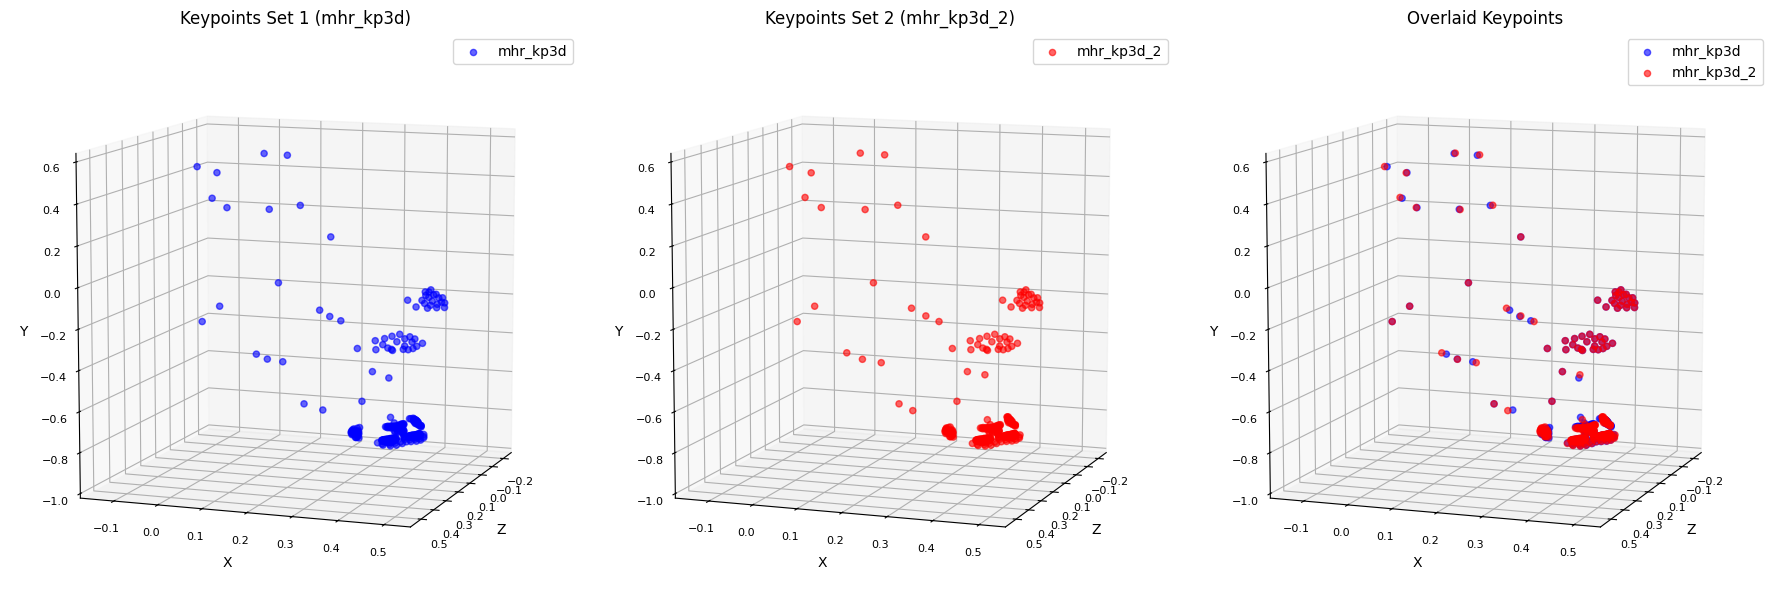

: 

In [ ]:
import cv2 
import os 
import torch

import numpy as np

BEDLAM_PATH = "/scratches/columbo2/cq244/BEDLAM/data/"
CKPT_PATH = "/scratches/columbo2/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt"
PATH = "/scratches/columbo2/cq244/BEDLAM/data/training_labels/all_npz_12_training_extra_mhr/20221013_3_250_batch01hand_orbit_bigOffice_6fps.npz"


data = np.load(PATH)
print(list(data.keys()))
print(data['center'].shape, data['scale'].shape)
index = 100


state_dict = torch.load(CKPT_PATH)
mapping = state_dict['head_pose.keypoint_mapping']
mapping = mapping.to(device)
print(mapping.shape)



device = "cuda" if torch.cuda.is_available() else "cpu"
mhr_model = torch.jit.load(
    "/scratches/columbo2/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt",
    map_location=device,
).to(device)



mhr_output = mhr_model(
    identity_coeffs=torch.from_numpy(data['identity_coeffs'][[index]]).to(device),
    model_parameters=torch.from_numpy(data['lbs_model_params'][[index]]).to(device),
    face_expr_coeffs=torch.from_numpy(data['face_expr_coeffs'][[index]]).to(device),
    apply_correctives=True,
)
mhr_verts, mhr_skeleton_state = mhr_output # 127, 8
mhr_j3d = mhr_skeleton_state[..., :3] 
mhr_verts /= 100.0
mhr_j3d /= 100.0

mhr_verts_joints = torch.cat([mhr_verts, mhr_j3d], dim=1)
print(mhr_verts_joints.shape)

mhr_kp3d = mapping @ mhr_verts_joints.permute(1, 0, 2).flatten(1, 2)
mhr_kp3d = mhr_kp3d.reshape(-1, mhr_verts_joints.shape[0], 3).permute(1, 0, 2)

print(mhr_kp3d.shape)


random_identity = torch.randn_like(torch.from_numpy(data['identity_coeffs'][[index]]))
mhr_output_2 = mhr_model(
    identity_coeffs=random_identity.to(device),
    model_parameters=torch.from_numpy(data['lbs_model_params'][[index]]).to(device),
    face_expr_coeffs=torch.from_numpy(data['face_expr_coeffs'][[index]]).to(device),
    apply_correctives=True,
)
mhr_verts_2, mhr_skeleton_state_2 = mhr_output_2 # 127, 8
mhr_j3d_2 = mhr_skeleton_state_2[..., :3] 
mhr_verts_2 /= 100.0
mhr_j3d_2 /= 100.0

mhr_verts_joints_2 = torch.cat([mhr_verts_2, mhr_j3d_2], dim=1)
print(mhr_verts_joints_2.shape)

mhr_kp3d_2 = mapping @ mhr_verts_joints_2.permute(1, 0, 2).flatten(1, 2)
mhr_kp3d_2 = mhr_kp3d_2.reshape(-1, mhr_verts_joints_2.shape[0], 3).permute(1, 0, 2)

diff = mhr_kp3d - mhr_kp3d_2
print(diff.abs().max())

# Convert to numpy for visualization
mhr_kp3d_np = mhr_kp3d[0].cpu().detach().numpy()  # [308, 3]
mhr_kp3d_2_np = mhr_kp3d_2[0].cpu().detach().numpy()  # [308, 3]

# Visualize in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 6))

# Plot 1: First set of keypoints
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(mhr_kp3d_np[:, 0], mhr_kp3d_np[:, 1], mhr_kp3d_np[:, 2], 
           c='blue', s=20, alpha=0.6, label='mhr_kp3d')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Keypoints Set 1 (mhr_kp3d)')
ax1.legend()
ax1.set_box_aspect([1,1,1])  # Equal aspect ratio
ax1.tick_params(axis='both', which='major', labelsize=8)

# Plot 2: Second set of keypoints
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(mhr_kp3d_2_np[:, 0], mhr_kp3d_2_np[:, 1], mhr_kp3d_2_np[:, 2], 
           c='red', s=20, alpha=0.6, label='mhr_kp3d_2')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Keypoints Set 2 (mhr_kp3d_2)')
ax2.legend()
ax2.set_box_aspect([1,1,1])  # Equal aspect ratio
ax2.tick_params(axis='both', which='major', labelsize=8)

# Plot 3: Overlaid
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(mhr_kp3d_np[:, 0], mhr_kp3d_np[:, 1], mhr_kp3d_np[:, 2], 
           c='blue', s=20, alpha=0.6, label='mhr_kp3d')
ax3.scatter(mhr_kp3d_2_np[:, 0], mhr_kp3d_2_np[:, 1], mhr_kp3d_2_np[:, 2], 
           c='red', s=20, alpha=0.6, label='mhr_kp3d_2')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Overlaid Keypoints')
ax3.legend()
ax3.set_box_aspect([1,1,1])  # Equal aspect ratio
ax3.tick_params(axis='both', which='major', labelsize=8)

# Set the same axis limits for all plots for fair comparison
all_points = np.concatenate([mhr_kp3d_np, mhr_kp3d_2_np], axis=0)
x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()
z_min, z_max = all_points[:, 2].min(), all_points[:, 2].max()

# Add some padding
x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
padding = 0.1

for ax in [ax1, ax2, ax3]:
    ax.set_xlim([x_min - padding * x_range, x_max + padding * x_range])
    ax.set_ylim([y_min - padding * y_range, y_max + padding * y_range])
    ax.set_zlim([z_min - padding * z_range, z_max + padding * z_range])
    ax.view_init(elev=10, azim=20, vertical_axis='y')

plt.tight_layout()
plt.show()







In [11]:
print(mapping)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
